# SolarScan — 04 · CNN par transfer learning (ResNet-18)

Objectif : **battre le baseline** du notebook 03 en exploitant la structure spatiale des images.

**Idée du transfer learning :** au lieu d'entraîner un réseau de zéro, on part d'un **ResNet-18 déjà entraîné sur ImageNet** (des millions d'images). Il sait déjà détecter bords, textures, formes. On remplace juste sa **dernière couche** par une couche à **12 sorties** (nos classes), et on ré-entraîne. → efficace même avec peu de données.

## ⚡ À lancer sur Google Colab (GPU gratuit)
1. Va sur [colab.research.google.com](https://colab.research.google.com) → **File → Upload notebook** → choisis ce fichier.
2. **Runtime → Change runtime type → GPU**.
3. **Runtime → Run all**. La cellule de setup télécharge les données et recrée les splits automatiquement.

*(En local sans GPU, ça marche aussi mais c'est lent : il utilisera `data/` et `splits/` déjà présents.)*

## 0. Environnement, dépendances et données

In [ ]:
%pip install -q torch torchvision scikit-learn pandas pillow matplotlib

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device :', device)

Device : cuda


In [2]:
# Localise les donnees ; sur Colab, les telecharge et recree les splits si besoin.
DATA_DIR = Path('data') if Path('data').exists() else Path('../data')
SPLITS = Path('splits') if Path('splits').exists() else Path('../splits')

if not (DATA_DIR / 'module_metadata.json').exists():
    import urllib.request, zipfile, shutil
    print('Telechargement du dataset...')
    url = 'https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip'
    urllib.request.urlretrieve(url, 'solar.zip')
    with zipfile.ZipFile('solar.zip') as z:
        z.extractall('tmp')
    shutil.move('tmp/InfraredSolarModules', 'data')
    DATA_DIR = Path('data')
    print('Dataset pret.')

if not (SPLITS / 'train.csv').exists():
    from sklearn.model_selection import train_test_split
    with open(DATA_DIR / 'module_metadata.json', encoding='utf-8') as f:
        meta = json.load(f)
    data = pd.DataFrame([{'filepath': v['image_filepath'], 'classe': v['anomaly_class']}
                         for v in meta.values()])
    tr, tmp = train_test_split(data, test_size=0.30, stratify=data['classe'], random_state=42)
    va, te = train_test_split(tmp, test_size=0.50, stratify=tmp['classe'], random_state=42)
    SPLITS = Path('splits'); SPLITS.mkdir(exist_ok=True)
    tr.to_csv(SPLITS / 'train.csv', index=False)
    va.to_csv(SPLITS / 'val.csv', index=False)
    te.to_csv(SPLITS / 'test.csv', index=False)
    print('Splits recrees.')

print('DATA_DIR =', DATA_DIR.resolve())
print('SPLITS   =', SPLITS.resolve())

Telechargement du dataset...
Dataset pret.
Splits recrees.
DATA_DIR = /content/data
SPLITS   = /content/splits


## 1. Dataset & DataLoaders

On prépare les images pour ResNet :
- **Grayscale → 3 canaux** (ResNet attend des images couleur) ;
- **Resize 224×224** (taille d'entrée d'ImageNet) ;
- **Augmentation** sur le train (flip, rotation) pour limiter le surapprentissage ;
- **Normalisation** avec les stats d'ImageNet.

In [3]:
CLASSES = sorted(pd.read_csv(SPLITS / 'train.csv')['classe'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print('Classes :', CLASSES)

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class SolarDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(DATA_DIR / row['filepath'])
        return self.transform(img), CLASS_TO_IDX[row['classe']]

# num_workers=2 sur Colab/Linux. Sur Windows, mets 0 si ca bloque.
train_ds = SolarDataset(SPLITS / 'train.csv', train_tf)
val_ds = SolarDataset(SPLITS / 'val.csv', eval_tf)
test_ds = SolarDataset(SPLITS / 'test.csv', eval_tf)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)
print('train/val/test :', len(train_ds), len(val_ds), len(test_ds))

Classes : ['Cell', 'Cell-Multi', 'Cracking', 'Diode', 'Diode-Multi', 'Hot-Spot', 'Hot-Spot-Multi', 'No-Anomaly', 'Offline-Module', 'Shadowing', 'Soiling', 'Vegetation']
train/val/test : 14000 3000 3000


## 2. Le modèle — ResNet-18 pré-entraîné

On charge ResNet-18 avec ses poids ImageNet, puis on **remplace la dernière couche** (`fc`) par une couche à 12 sorties.

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)
print('Derniere couche :', model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s]


Derniere couche : Linear(in_features=512, out_features=12, bias=True)


## 3. Perte pondérée + optimiseur

Comme en EDA on a vu le déséquilibre, on **pondère la perte** par classe : les classes rares pèsent plus, le modèle ne peut pas les ignorer.

In [5]:
y_train = pd.read_csv(SPLITS / 'train.csv')['classe'].map(CLASS_TO_IDX).values
weights = compute_class_weight('balanced', classes=np.arange(len(CLASSES)), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print('Poids des classes prets.')

Poids des classes prets.


## 4. Entraînement

À chaque epoch : on apprend sur le **train**, puis on mesure le **macro-F1** sur la **validation**. On sauvegarde le meilleur modèle.

> ⏳ Sur GPU Colab : ~1-2 min/epoch. Sur CPU : beaucoup plus.

In [6]:
EPOCHS = 10
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    train_loss = running / len(train_ds)

    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in val_dl:
            preds += model(x.to(device)).argmax(1).cpu().tolist()
            gts += y.tolist()
    val_f1 = f1_score(gts, preds, average='macro')
    print(f'Epoch {epoch+1}/{EPOCHS} - loss {train_loss:.3f} - val macro-F1 {val_f1:.3f}')

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pt')

print('Meilleur val macro-F1 :', round(best_f1, 3))

Epoch 1/10 - loss 2.027 - val macro-F1 0.164
Epoch 2/10 - loss 1.571 - val macro-F1 0.365
Epoch 3/10 - loss 1.372 - val macro-F1 0.313
Epoch 4/10 - loss 1.321 - val macro-F1 0.424
Epoch 5/10 - loss 1.198 - val macro-F1 0.467
Epoch 6/10 - loss 1.104 - val macro-F1 0.497
Epoch 7/10 - loss 1.033 - val macro-F1 0.498
Epoch 8/10 - loss 0.982 - val macro-F1 0.380
Epoch 9/10 - loss 0.917 - val macro-F1 0.377
Epoch 10/10 - loss 0.907 - val macro-F1 0.504
Meilleur val macro-F1 : 0.504


## 5. Évaluation finale sur le test

On recharge le meilleur modèle et on le juge sur des données **jamais vues**.

In [7]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

preds, gts = [], []
with torch.no_grad():
    for x, y in test_dl:
        preds += model(x.to(device)).argmax(1).cpu().tolist()
        gts += y.tolist()

print('Test accuracy :', round(accuracy_score(gts, preds), 3))
print('Test macro-F1 :', round(f1_score(gts, preds, average='macro'), 3))
print()
print(classification_report(gts, preds, target_names=CLASSES))

Test accuracy : 0.578
Test macro-F1 : 0.487

                precision    recall  f1-score   support

          Cell       0.51      0.32      0.39       281
    Cell-Multi       0.38      0.53      0.44       193
      Cracking       0.81      0.43      0.56       141
         Diode       0.89      0.89      0.89       225
   Diode-Multi       0.58      0.96      0.72        26
      Hot-Spot       0.25      0.30      0.27        37
Hot-Spot-Multi       0.18      0.59      0.28        37
    No-Anomaly       0.95      0.57      0.71      1500
Offline-Module       0.25      0.64      0.36       124
     Shadowing       0.30      0.75      0.42       159
       Soiling       0.13      0.61      0.22        31
    Vegetation       0.52      0.63      0.57       246

      accuracy                           0.58      3000
     macro avg       0.48      0.60      0.49      3000
  weighted avg       0.73      0.58      0.61      3000



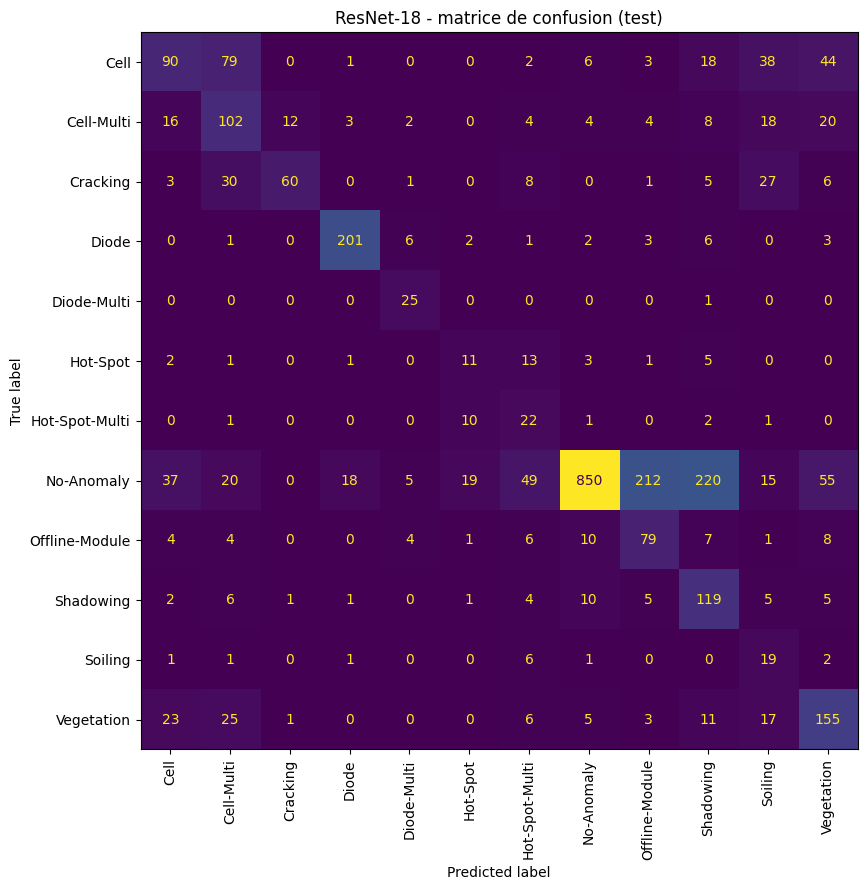

In [8]:
cm = confusion_matrix(gts, preds)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, xticks_rotation=90, colorbar=False)
plt.title('ResNet-18 - matrice de confusion (test)')
plt.tight_layout()
plt.show()

## 6. Bilan

**Compare au baseline (notebook 03) :**

| Modèle | Macro-F1 (test) |
|---|---|
| Dummy | ~0.06 |
| Random Forest | _ton score 03_ |
| **ResNet-18 (transfer learning)** | **_ce notebook_** |

L'écart RF → ResNet mesure l'apport de la **vision spatiale**.

**Pistes d'amélioration (si le temps le permet) :**
- Plus d'epochs + *learning rate scheduler* ;
- Geler les premières couches puis fine-tuner (vrai transfer learning en 2 temps) ;
- Tester EfficientNet ou un ResNet plus profond ;
- Grad-CAM pour visualiser *où* le modèle regarde (notebook 05).

➡️ Une fois ton macro-F1 obtenu, on le reporte dans le **README et le CV** (chiffres réels !).